In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LightSource
import matplotlib.animation as animation
import scipy as sp

In [2]:
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times']})
rc('text', usetex=True)

In [3]:
graph_nums = [1, 1, 1, 2, 6, 21, 112, 853, 11117, 261080, 11716571]

In [4]:
n_qubits = 8
graph_type = "dc"
qubitstate_size = 2**n_qubits

In [5]:

_x, _y, _z = np.arange(0,n_qubits,1), np.arange(0,n_qubits,1), np.arange(0,n_qubits,1)
_xx, _yy, __zz = np.meshgrid(_x, _y, _z, indexing="ij")
x, y, z = _xx.ravel(), _yy.ravel(), __zz.ravel()
u, v = np.mgrid[0:2*np.pi:50j, 0:np.pi:50j]

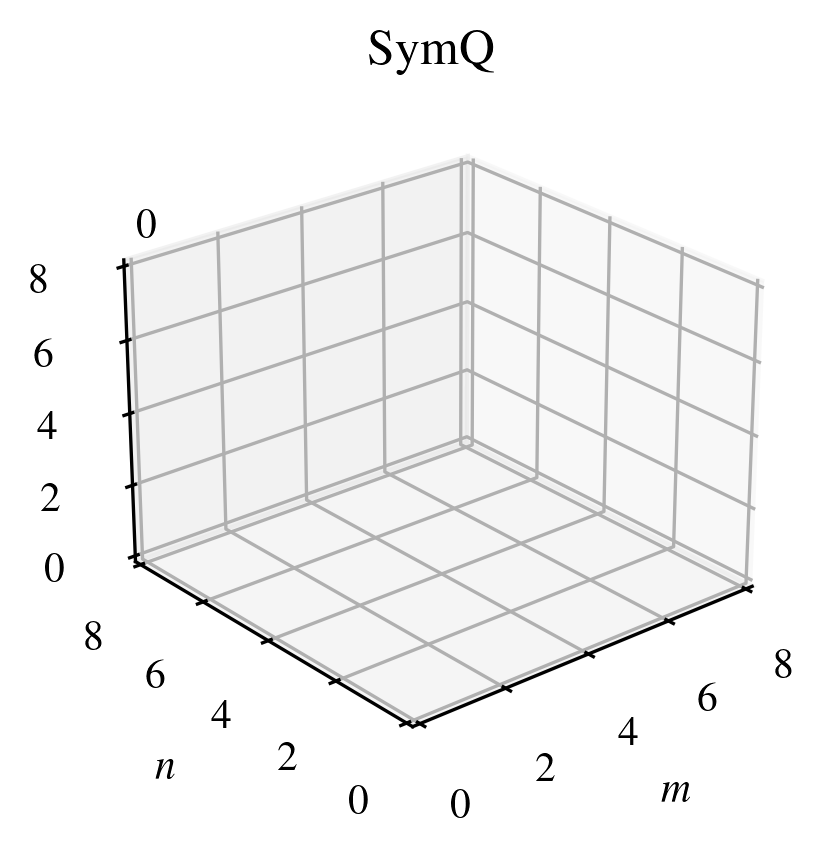

In [6]:
light = LightSource(0,20)
fig = plt.figure(figsize=(4,3),dpi=300)
ax = fig.add_subplot(projection='3d')
ax.set_title("SymQ")
ax.view_init(elev=25,azim=-130)
ax.set_xlabel(r'$m$')
ax.set_ylabel(r'$n$')
ax.set_zlabel(r'$k$')
ax.set_xlim(0,n_qubits)
ax.set_ylim(0,n_qubits)
ax.set_zlim(0,n_qubits)
text = ax.text(0, n_qubits, 1.1*n_qubits, "0")

In [7]:
def update(frame):
    ax.cla()  # clear previous frame

    filename = "characteristic/q" + str(n_qubits) + "_" + str(frame+1) + ".txt"
    charac = np.genfromtxt("C:/dev/StabilizerStates/data/symQfuncs/"+filename, usecols = 0, delimiter=",", dtype = float)
    charac = np.reshape(charac,(n_qubits+1,n_qubits+1,n_qubits+1))
    max_charac = np.max(charac)
    text.set_text(str(frame+1))

    for (i,j,k) in zip(x,y,z):
        r = charac[i,j,k] / max_charac
        if r > 0.05:
            s_x = r*np.cos(u)*np.sin(v)
            s_y = r*np.sin(u)*np.sin(v)
            s_z = r*np.cos(v)

            ax.plot_surface(s_x+i, s_y+j, s_z+k, color = 'b', alpha=0.5)

In [8]:

anim = animation.FuncAnimation(
    fig,
    update,
    frames=graph_nums[n_qubits],
    interval=100,   # ms between frames
    blit=False      # blitting does NOT work with 3D
)

In [ ]:
WriterClass = animation.writers['ffmpeg']
writer = WriterClass(fps=60, metadata=dict(artist='bww'), bitrate=1800)
anim.save("C:/dev/StabilizerStates/plots/characteristic/q_" + str(n_qubits) + ".mp4", writer=writer)